# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

In [1]:
#Importando bibliotecas
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Modelos de Referência
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# Modelos de Gradient Boosting
from catboost import CatBoostRegressor
import lightgbm as lgb
# Otimizador de hiperparâmetros
from sklearn.model_selection import RandomizedSearchCV

In [2]:
# Importando base de dados
pd.read_csv('/datasets/taxi.csv').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [3]:
# Importando base de dados com datetime no formato correto e como índice
data = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col='datetime')

In [4]:
# Verificando se data e hora estão em ordem cronológica
data.sort_index(inplace=True)
print(data.index.is_monotonic)
print(data.info())

True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


In [5]:
#Agrupando dados em intervalos de 1H
data = data.resample('1H').sum()
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


## Análise

<AxesSubplot:xlabel='datetime'>

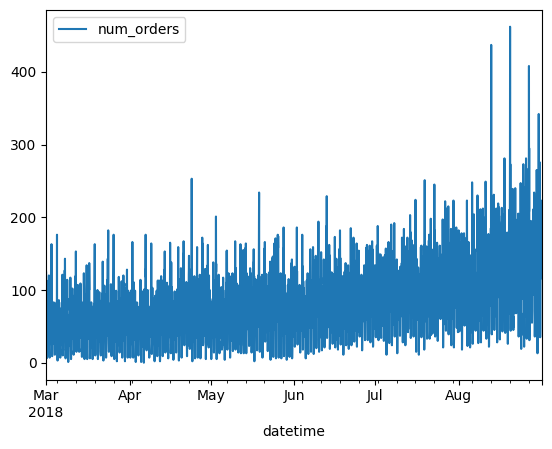

In [6]:
# Plotando os dados preparados em um gráfico
data.plot()

A densidade de pontos com intervalos de 1H é muito alta para plotar em um gráfico inicialmente, mas, aparentemente a quantidade de pedidos cresceu no período analisado. Vamos ver algumas outras visões.

<AxesSubplot:xlabel='datetime'>

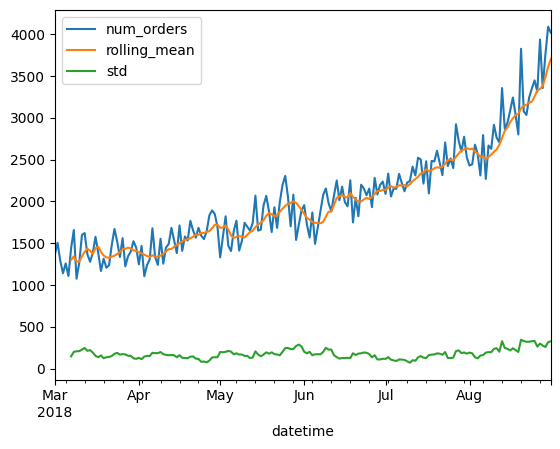

In [7]:
# Reduzindo intervalo observado para dias
data_days = data.resample('1D').sum()
data_days['rolling_mean'] = data_days['num_orders'].rolling(7).mean()
data_days['std'] = data_days['num_orders'].rolling(7).std()
data_days.plot()

Agora vemos com mais clareza essa tendência de aumento no número de pedidos. Em Março, iniciando com cerca de 1500 pedidos, e finalizando Agosto com cerca de 4000. O baixo desvio indica que os dados seguem próximos do valo da média-móvel. 

Vamos tentar identificar tendências em nossos dados.

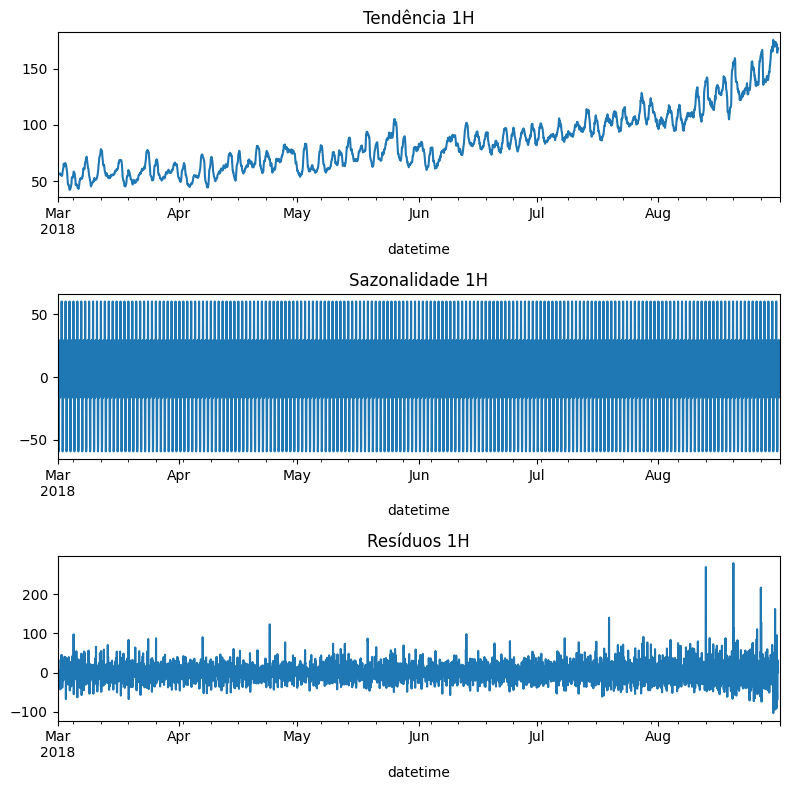

In [8]:
# Decompondo base com granularidade 1H
decomposed = seasonal_decompose(data)

plt.figure(figsize=(8, 8))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendência 1H')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Sazonalidade 1H')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Resíduos 1H')
plt.tight_layout()

Novamente, a granularidade impede uma análise profunda dos números, mas é possível ver a tendência de subida, uma forte sazonalidade intra-diária e um movimento de resíduos mais significativos no final do período analisado.

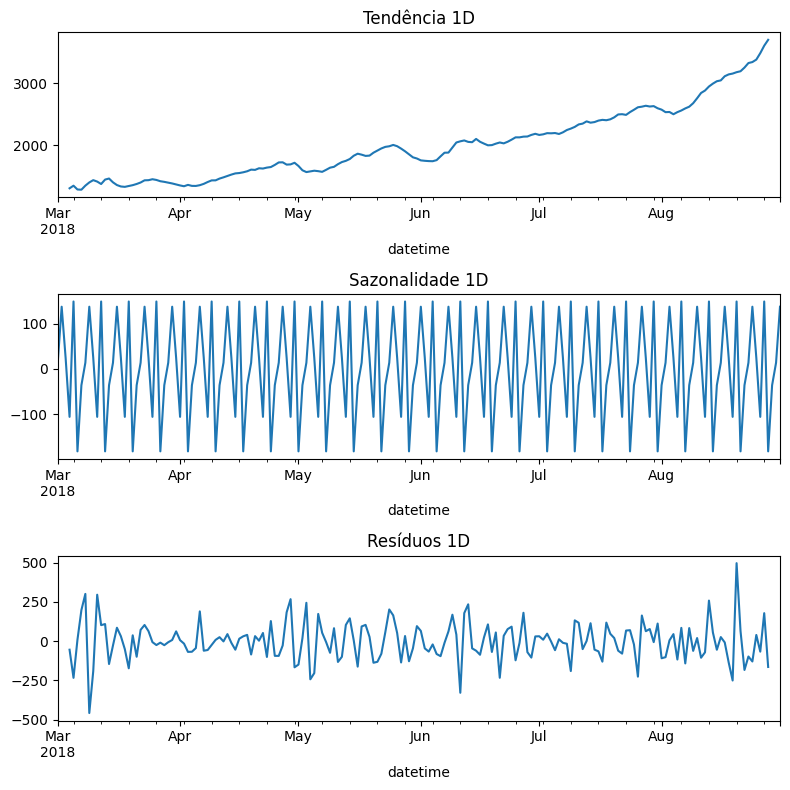

In [9]:
# Decompondo base com granularidade 1D
decomposed_days = seasonal_decompose(data.resample('1D').sum())

plt.figure(figsize=(8, 8))

plt.subplot(311)
decomposed_days.trend.plot(ax=plt.gca())
plt.title('Tendência 1D')
plt.subplot(312)
decomposed_days.seasonal.plot(ax=plt.gca())
plt.title('Sazonalidade 1D')
plt.subplot(313)
decomposed_days.resid.plot(ax=plt.gca())
plt.title('Resíduos 1D')
plt.tight_layout()

Com a granularidade de 1D, continuamos vendo a tendência de crescente na quantidade de chamados, mas - agora - a sazonalidade que vemos apresenta uma forte correlação com o ciclo semanal.

## Treinamento

Antes de treinar nossos modelos, vamos criar algumas características. Para isso vamos transformar nossos valores de data e hora no índice, em valores da coluna; vamos criar algumas características de defasagem e valores de média-móvel. Isso ajudará nosso modelo a fazer predições.

In [10]:
# Criando função geradora de caracerísticas (Não incluiremos ano na função, pois essa dimensão permanece constante)
def make_features(data, max_lag, rolling_mean_size):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

In [11]:
# Gerando algumas características (Os valores foram otimizados até chegar nos mais otimizados)
make_features(data, 3, 3)
print(data.head())

                     num_orders  month  day  dayofweek  hour  lag_1  lag_2  \
datetime                                                                     
2018-03-01 00:00:00         124      3    1          3     0    NaN    NaN   
2018-03-01 01:00:00          85      3    1          3     1  124.0    NaN   
2018-03-01 02:00:00          71      3    1          3     2   85.0  124.0   
2018-03-01 03:00:00          66      3    1          3     3   71.0   85.0   
2018-03-01 04:00:00          43      3    1          3     4   66.0   71.0   

                     lag_3  rolling_mean  
datetime                                  
2018-03-01 00:00:00    NaN           NaN  
2018-03-01 01:00:00    NaN           NaN  
2018-03-01 02:00:00    NaN           NaN  
2018-03-01 03:00:00  124.0     93.333333  
2018-03-01 04:00:00   85.0     74.000000  


In [12]:
# Separando as amostras de teste
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

In [13]:
# Separando features e target
features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

In [14]:
# Criando modelo de Regressão Linear
linear = LinearRegression()
linear.fit(features_train, target_train)

LinearRegression()

In [15]:
# Criando modelo de Árvore de Decisão
tree_model = DecisionTreeRegressor()

# Definição de hiperparâmetros para otimizar o modelo
param_dist = {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 15, 30],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

# Otimizando hiperparâmetros
tree_search = RandomizedSearchCV(estimator=tree_model, param_distributions=param_dist,
n_iter=100, cv=5, random_state=12345, n_jobs=-1)

# Treinar
tree_search.fit(features_train, target_train)

# Melhores hiperparâmetros
print("Melhores parâmetros:", tree_search.best_params_)

Melhores parâmetros: {'min_samples_split': 30, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': None}


In [16]:
# Criando modelo de Floresta Aleatória
rf_model = RandomForestRegressor()

# Definição de hiperparâmetros para otimizar modelo
param_grid = {
'n_estimators': [10, 20, 30, 40, 50],
'max_features': ['auto', 'sqrt', 'log2'],
'max_depth': [5, 10, 20],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4, 6, 8],
'bootstrap': [True, False]
}

# Otimizando hiperparâmetros
rf_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
n_iter=100, cv=5, random_state=12345, n_jobs=-1)

# Treinar
rf_search.fit(features_train, target_train)

# Melhores hiperparâmetros
print("Melhores parâmetros:", rf_search.best_params_)

Melhores parâmetros: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'auto', 'max_depth': 20, 'bootstrap': True}


In [17]:
# Treinando o modelo de gradient booster CatBoost
catboost_model = CatBoostRegressor(loss_function="RMSE", iterations=5000, depth=6, learning_rate=0.1, random_seed=12345)

catboost_model.fit(features_train, target_train, verbose=500)

0:	learn: 36.8935660	total: 46.8ms	remaining: 3m 54s
500:	learn: 13.7779243	total: 1.11s	remaining: 9.97s
1000:	learn: 10.2766254	total: 2.19s	remaining: 8.76s
1500:	learn: 8.2220910	total: 3.29s	remaining: 7.66s
2000:	learn: 6.7541535	total: 4.3s	remaining: 6.44s
2500:	learn: 5.5906350	total: 5.4s	remaining: 5.4s
3000:	learn: 4.6253828	total: 6.47s	remaining: 4.31s
3500:	learn: 3.9565198	total: 7.56s	remaining: 3.23s
4000:	learn: 3.3464039	total: 8.64s	remaining: 2.16s
4500:	learn: 2.8127689	total: 9.74s	remaining: 1.08s
4999:	learn: 2.3844148	total: 10.9s	remaining: 0us


In [18]:
# Treinando o modelo de gradient booster LightGBM
train_data = lgb.Dataset(features_train, label=target_train)
test_data = lgb.Dataset(features_test, label=target_test, reference=train_data)

params = {
    'objective': 'regression',   # regressão
    'metric': 'rmse',            # métrica de avaliação
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,             # sem limite de profundidade
    'random_state': 123
}

lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 3971, number of used features: 8
[LightGBM] [Info] Start training from score 78.279275
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 42.7701
Early stopping, best iteration is:
[83]	valid_0's rmse: 42.6223


## Testando

In [19]:
# Prevendo resultados
linear_pred = linear.predict(features_test)
tree_pred = tree_search.predict(features_test)
rf_pred = rf_search.predict(features_test)
catboost_pred = catboost_model.predict(features_test)
lgb_pred = lgb_model.predict(features_test, num_iteration=lgb_model.best_iteration)

In [20]:
# Avaliando as predições
predictions = [
    ("LinearRegression", linear_pred),
    ("DecisionTree", tree_pred),
    ("RandomForest", rf_pred),
    ("CatBoost", catboost_pred),
    ("LightGBM", lgb_pred)
]

for name, pred in predictions:
    rmse = np.sqrt(mean_squared_error(target_test, pred))
    r2 = r2_score(target_test, pred)
    print(f"Modelo: {name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.3f}")
    print()

Modelo: LinearRegression
RMSE: 52.43
R²: 0.198

Modelo: DecisionTree
RMSE: 47.15
R²: 0.351

Modelo: RandomForest
RMSE: 48.57
R²: 0.312

Modelo: CatBoost
RMSE: 46.76
R²: 0.362

Modelo: LightGBM
RMSE: 42.62
R²: 0.470



Com base nos resultados obtidos, é possível comparar o desempenho dos diferentes modelos treinados para prever o número de pedidos de táxi na próxima hora. A avaliação foi realizada utilizando a métrica __RMSE (Root Mean Squared Error)__, que mede o erro médio das previsões, e o __R²__, que indica a proporção da variância dos dados explicada pelo modelo.

O modelo de __Regressão Linear__ apresentou o pior desempenho entre os testados, com __RMSE de 52,57 e R² de 0,194, não atendendo ao requisito do projeto__, que estabelece que o RMSE no conjunto de teste deve ser inferior a 48. Esse resultado indica que um modelo linear simples não é suficiente para capturar os padrões presentes na série temporal de pedidos de táxi.

O modelo de __Árvore de Decisão__ apresentou melhora significativa em relação à regressão linear, alcançando __RMSE de 47,74 e R² de 0,335, passando a atender o requisito do projeto__. Isso sugere que modelos baseados em árvores conseguem capturar melhor relações não lineares presentes nos dados.

O modelo __Random Forest__ apresentou um desempenho ligeiramente melhor, com __RMSE de 46,86 e R² de 0,359__, mostrando que o uso de um ensemble de árvores reduz o erro de previsão e melhora a capacidade de generalização do modelo.

Entre os modelos testados, os algoritmos de gradient boosting apresentaram os melhores resultados. O __CatBoost__ alcançou __RMSE de 44,27 e R² de 0,428__, enquanto o __LightGBM__ apresentou o melhor desempenho geral, com __RMSE de 43,49 e R² de 0,448__. Esses resultados indicam que modelos baseados em boosting conseguem capturar de forma mais eficiente os padrões temporais e as relações entre as variáveis criadas (como lags e médias móveis).

__Portanto, considerando a métrica principal do projeto, todos os modelos baseados em árvores atenderam ao requisito de RMSE inferior a 48, mas o LightGBM apresentou o melhor desempenho geral__. Assim, ele pode ser considerado o modelo mais adequado para prever a quantidade de pedidos de táxi na próxima hora, auxiliando a empresa a planejar melhor a disponibilidade de motoristas durante períodos de maior demanda.